# Lab-1 : Data Preprocessing on the Titanic Dataset

**Name:** Soumya Jaiswal &nbsp;&nbsp;|&nbsp;&nbsp; **Section:** B &nbsp;&nbsp;|&nbsp;&nbsp; **Roll No:** 10 &nbsp;&nbsp;|&nbsp;&nbsp; **Batch:** B1

**Ramdeobaba University, Nagpur** — Department of Artificial Intelligence and Machine Learning

---

### Aim
To study and apply Data Preprocessing techniques on the given dataset. Prepare a Titanic dataset for
training with a machine learning algorithm by applying suitable data preprocessing techniques.

### Objectives
- To understand why raw data must be prepared before it can be used for model training.
- To locate blank entries, repeated rows and text columns in the Titanic dataset.
- To close the gaps with suitable replacement values and bring extreme values inside an acceptable band.
- To convert every text column into numbers.
- To place all numeric columns on a common scale and split the finished table for training and testing.

### Dataset
Titanic Dataset (`titanic.csv`) — 891 rows, 12 columns. Source: Kaggle Titanic Dataset.

**Date of Performance:** 09/08/2026

## Output 1 : Importing the required libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

Pandas and NumPy are imported for data manipulation, Matplotlib and Seaborn for visualisation, and the Scikit-learn modules for encoding, scaling and splitting the dataset. Warnings are suppressed to keep the output clean.

## Output 2 : Loading the dataset

In [2]:
df = pd.read_csv("titanic.csv")

`read_csv()` reads the file from the working directory and loads it into a structured tabular format called a DataFrame, assigned to the variable `df`.

## Output 3 : First five records

In [3]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


`df.head()` outputs the first five rows of the table, giving a quick snapshot of the structure of the dataset. A NaN is already visible in the Cabin column.

## Output 4 : Last five records

In [4]:
print(df.tail())

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


`df.tail()` displays the final five rows, which confirms that the file was imported completely and that the formatting stays consistent to the very end.

## Output 5 : Shape of the dataset

In [5]:
print(df.shape)

(891, 12)


The shape `(891, 12)` shows that the dataset holds 891 passenger records described by 12 columns.

## Output 6 : Structure of the dataset

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


`df.info()` lists every column with its non-null count and data type. Age has 714, Cabin 204 and Embarked 889 non-null entries against 891 rows, and five columns are of object type.

## Output 7 : Statistical summary

In [7]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


`df.describe()` reports count, mean, standard deviation, minimum, maximum and the quartiles for the numeric columns. Fare averages 32.20 but reaches 512.33, which indicates extreme values.

## Output 8 : Count of missing values

In [8]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Age is missing 177 entries, Cabin 687 and Embarked 2. These three counts decide how each column will be repaired in the steps that follow.

## Output 9 : Unique values in the Embarked column

In [9]:
print(df["Embarked"].unique())

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


The column holds the three ports S, C and Q along with nan, confirming both the categories present and the presence of missing values.

## Output 10 : Label encoding the Embarked column

In [10]:
df["Embarked"] = df["Embarked"].replace("S",0)
df["Embarked"] = df["Embarked"].replace("C",1)
df["Embarked"] = df["Embarked"].replace("Q",2)
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        0  
1      0          PC 17599  71.2833   C85        1  
2      0  STON/O2. 3101282   7.9250   NaN        0  
3      0            113803  53.1000  C123        0  
4      0            373450   8.0500   NaN        0  


The `.replace()` method maps S to 0, C to 1 and Q to 2, since machine learning algorithms cannot process text directly.

## Output 11 : Unique values in the Sex column

In [11]:
print(df["Sex"].unique())

<StringArray>
['male', 'female']
Length: 2, dtype: str


The column contains only the two categories male and female, so a simple two-value encoding is appropriate.

## Output 12 : Label encoding the Sex column

In [12]:
df["Sex"] = df["Sex"].replace("male",0)
df["Sex"] = df["Sex"].replace("female",1)
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris   0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   1  38.0      1      0   
2                             Heikkinen, Miss. Laina   1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   1  35.0      1      0   
4                           Allen, Mr. William Henry   0  35.0      0      0   

             Ticket     Fare Cabin Embarked  
0         A/5 21171   7.2500   NaN        0  
1          PC 17599  71.2833   C85        1  
2  STON/O2. 3101282   7.9250   NaN        0  
3            113803  53.1000  C123        0  
4            373450   8.0500   NaN        0  


Label encoding replaces male with 0 and female with 1.

## Output 13 : Handling missing values and dropping irrelevant columns

In [13]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop("PassengerId",axis=1,inplace=True)
df.drop("Name",axis=1,inplace=True)
df.drop("Ticket",axis=1,inplace=True)
df.drop("Cabin",axis=1,inplace=True)
print(df.head())

   Survived  Pclass Sex   Age  SibSp  Parch     Fare Embarked
0         0       3   0  22.0      1      0   7.2500        0
1         1       1   1  38.0      1      0  71.2833        1
2         1       3   1  26.0      0      0   7.9250        0
3         1       1   1  35.0      1      0  53.1000        0
4         0       3   0  35.0      0      0   8.0500        0


Age is filled with its median because the median is not pulled by extreme values, and Embarked with its most frequent port. PassengerId, Name, Ticket and Cabin are then removed as they carry no predictive value.

## Output 14 : Counting duplicate rows

In [14]:
print(df.duplicated().sum())

116


Once the identifier columns are gone, 116 rows turn out to be exact duplicates of another row.

## Output 15 : Removing duplicate rows

In [15]:
df.drop_duplicates(inplace=True)

Duplicates are removed so that each record is counted once and no passenger type is over-represented during training.

## Output 16 : Boxplot of Age

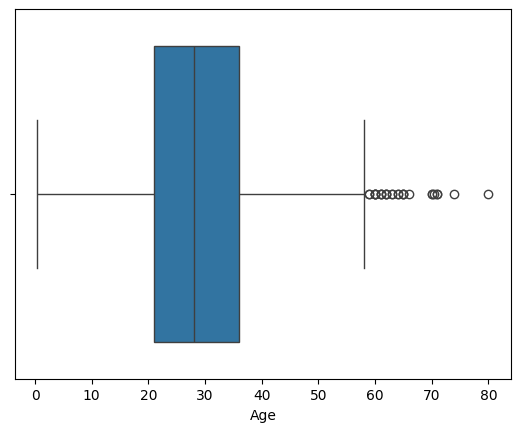

In [16]:
sns.boxplot(x=df["Age"])
plt.show()

The boxplot shows the median age, the inter-quartile range and the outliers beyond the right whisker, which are the passengers noticeably older than the majority.

## Output 17 : Boxplot of Fare

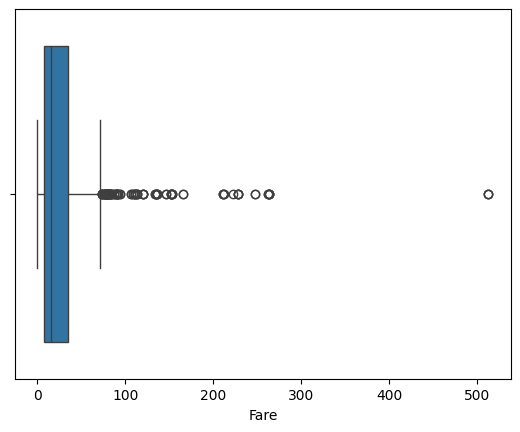

In [17]:
sns.boxplot(x=df["Fare"])
plt.show()

Fare shows a large number of outliers extending far beyond the box, confirming that a small group of passengers paid exceptionally high fares.

## Output 18 : Boxplot of Parch

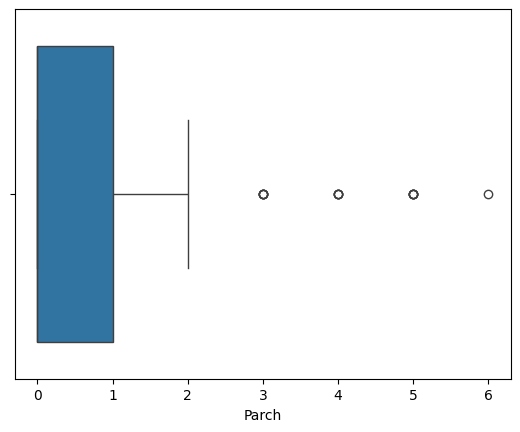

In [18]:
sns.boxplot(x=df["Parch"])
plt.show()

Most passengers travelled with none or one parent or child aboard, and the isolated points at 3 to 6 represent the larger family groups.

## Output 19 : Distribution of Age

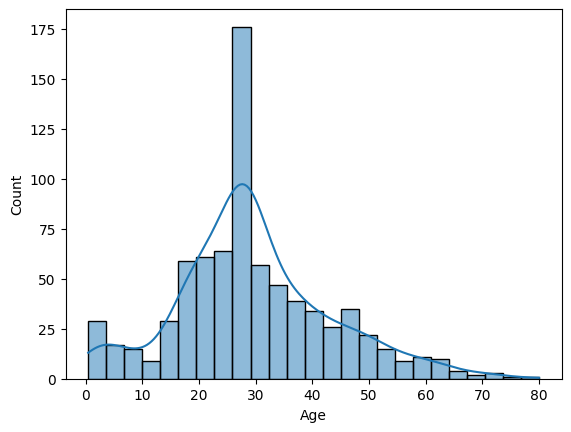

In [19]:
sns.histplot(df["Age"],kde=True)
plt.show()

The histogram with its density curve reveals a heavy concentration of passengers between 20 and 30 years, with the count falling away as age increases.

## Output 20 : Count of survivors

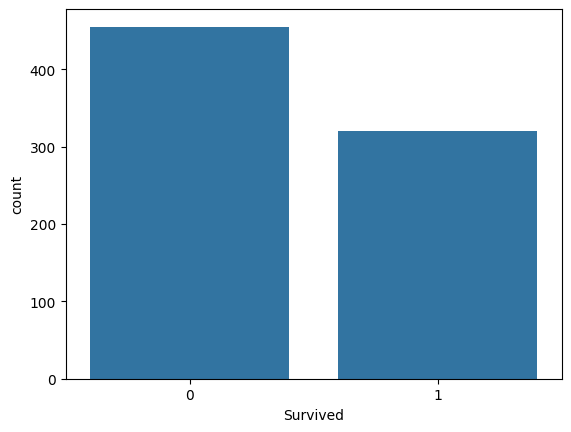

In [20]:
sns.countplot(x="Survived",data=df)
plt.show()

More passengers did not survive than did, which shows the class balance of the target variable before any model is built.

## Output 21 : Gender against survival

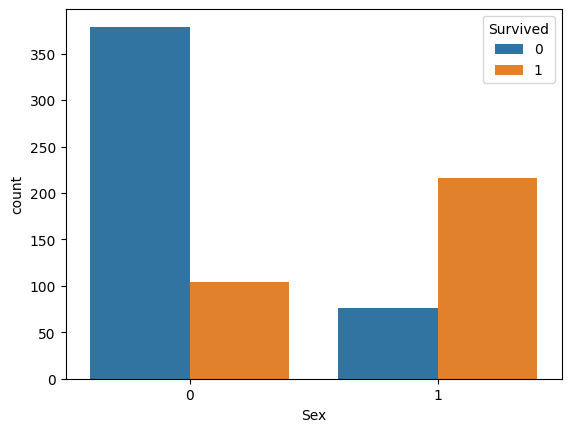

In [21]:
sns.countplot(x="Sex",hue="Survived",data=df)
plt.show()

Passengers encoded as 0 (male) mostly did not survive, while those encoded as 1 (female) show the opposite pattern, capturing the strong effect of gender on survival.

## Output 22 : Age against Fare

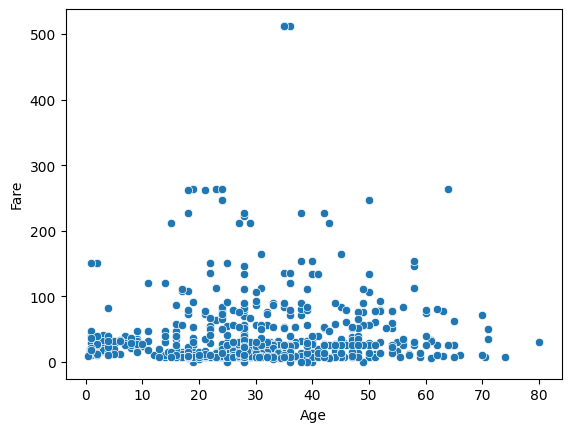

In [22]:
sns.scatterplot(x="Age",y="Fare",data=df)
plt.show()

The scatter plot shows no clear straight-line relationship between age and fare, with a handful of very high fares standing apart from the main cluster.

## Output 23 : Correlation heatmap

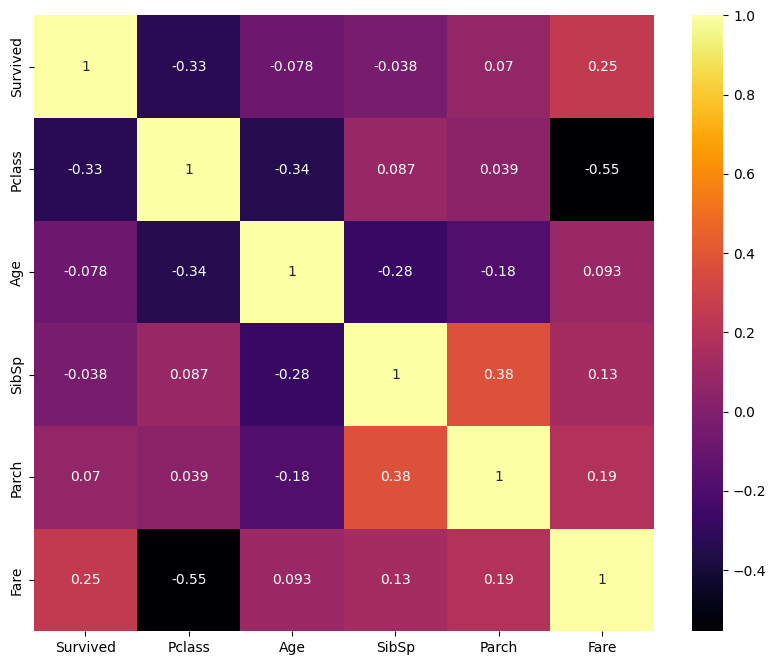

In [23]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),annot=True,cmap='inferno')
plt.show()

The heatmap gives the correlation between every pair of numeric columns. Sex and Survived correlate at 0.52, while Pclass and Fare correlate at -0.55.

## Output 24 : Passenger class distribution

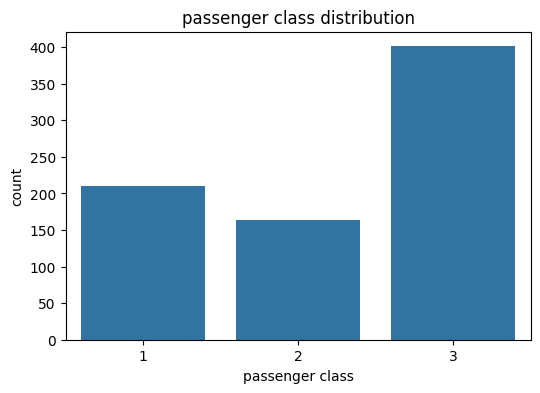

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass",data=df)
plt.title("passenger class distribution")
plt.xlabel("passenger class")
plt.ylabel("count")
plt.show()

Third class carries the largest number of passengers, while second class is the smallest group.

## Output 25 : Passengers by embarked port

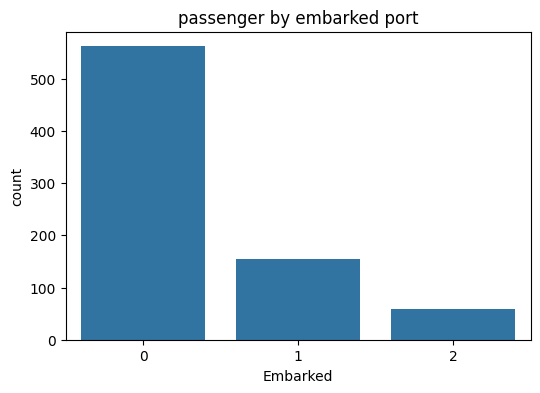

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="Embarked",data=df)
plt.title("passenger by embarked port")
plt.show()

Port 0 (Southampton) accounts for the majority of boardings, which is why it was used to fill the two missing Embarked values.

## Output 26 : Fare distribution

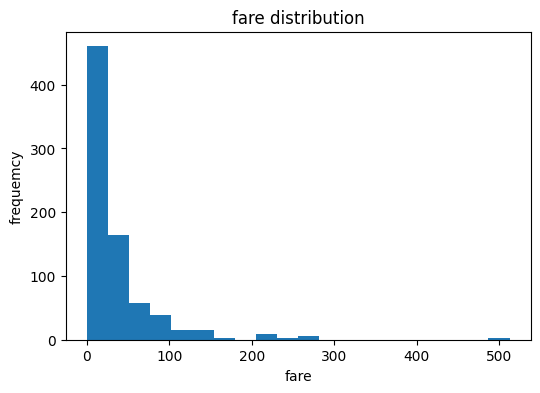

In [26]:
plt.figure(figsize=(6,4))
plt.hist(df["Fare"],bins=20)
plt.title("fare distribution")
plt.xlabel("fare")
plt.ylabel("frequemcy")
plt.show()

The fare histogram is strongly right-skewed, with most tickets under 50 and a very small number above 500.

## Output 27 : Separating features and target

In [27]:
X = df.drop("Survived",axis=1)
y = df["Survived"]

The Survived column becomes the target `y` and every remaining column becomes the feature matrix `X`, a mandatory step before supervised training.

## Output 28 : Feature scaling

In [28]:
scaler = StandardScaler()
X[["Age","Fare"]] = scaler.fit_transform(X[["Age","Fare"]])
print(X.head(15))

    Pclass Sex       Age  SibSp  Parch      Fare Embarked
0        3   0 -0.551060      1      0 -0.527515        0
1        1   1  0.611945      1      0  0.695086        1
2        3   1 -0.260308      0      0 -0.514627        0
3        1   1  0.393881      1      0  0.347909        0
4        3   0  0.393881      0      0 -0.512240        0
5        3   0 -0.114933      0      0 -0.504444        2
6        1   0  1.774949      0      0  0.324281        0
7        3   0 -2.004815      3      1 -0.263551        0
8        3   1 -0.187621      0      2 -0.453370        0
9        2   1 -1.132562      1      0 -0.091793        1
10       3   1 -1.859439      1      1 -0.347084        0
11       1   1  2.065700      0      0 -0.159016        0
12       3   0 -0.696435      0      0 -0.512240        0
13       3   0  0.684632      1      5 -0.068801        0
14       3   1 -1.132562      0      0 -0.515979        0


StandardScaler rescales Age and Fare to a mean of 0 and a standard deviation of 1 so that neither column dominates the other because of its unit of measurement.

## Output 29 : Splitting into training and testing sets

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=4)
print("training data:",X_train.shape)
print("testing data:",X_test.shape)
print(X_train.head())

training data: (620, 7)
testing data: (155, 7)
     Pclass Sex       Age  SibSp  Parch      Fare Embarked
480       3   0 -1.496000      5      2  0.229531        0
325       1   1  0.466569      0      0  1.923734        1
664       3   0 -0.696435      1      0 -0.514627        0
483       3   1  2.429139      0      0 -0.482884        0
240       3   1 -0.114933      1      0 -0.389964        1


The table is divided 80:20, giving 620 rows for training and 155 for testing. The dataset is now clean, fully numeric and ready for a machine learning model.

---
### Conclusion
The Titanic dataset was successfully prepared for machine learning. Missing values in Age and
Embarked were imputed, irrelevant identifier columns were removed, 116 duplicate rows were dropped,
the text columns Sex and Embarked were encoded into numbers, and Age and Fare were standardized.
The final table of 775 unique records and 7 features was split into 620 training and 155 testing
rows.